In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [3]:
df=pd.read_csv('dataset/StudentsPerformance.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

There are no missing values

In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
#numberical and categorical features
numeric_features=[feature for feature in df.columns if df[feature].dtype != 'object']
categorical_features=[feature for feature in df.columns if df[feature].dtype == 'object']

print(f'We have {len(numeric_features)} numerical features and these are {numeric_features}')
print(f'We have {len(categorical_features)} categorical features and these are {categorical_features}')

We have 3 numerical features and these are ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features and these are ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [13]:
#adding columns for total_marks and average
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['average']=df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:

import json

eda_summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "column_names": list(df.columns),
    "mean": df.mean(numeric_only=True).to_dict(),
    "median": df.median(numeric_only=True).to_dict(),
    "std": df.std(numeric_only=True).to_dict(),
    "target_value":"math_score"
}
with open("summary.json","w") as f:
    json.dump(eda_summary, f, indent=4)

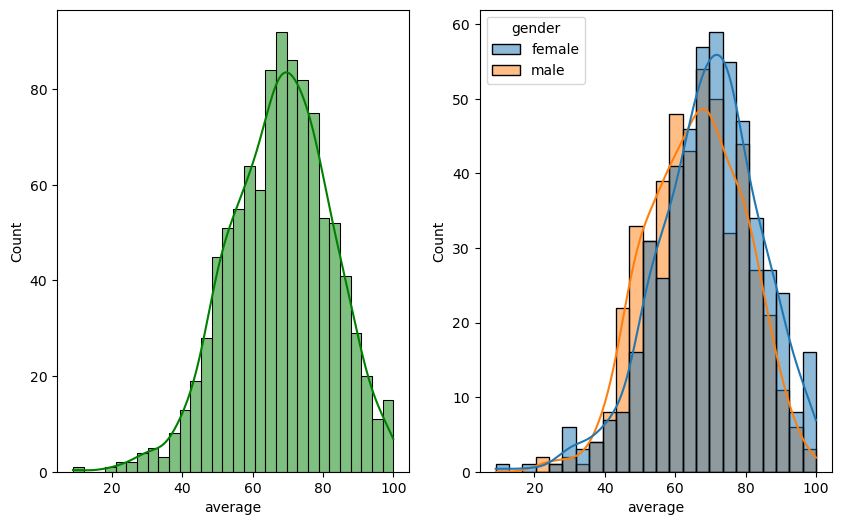

In [25]:
#EDA
fig, ax=plt.subplots(1, 2, figsize=(10,6))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='average', kde=True, hue='gender')
plt.savefig(
    "images/histogram.png"
)
plt.show()



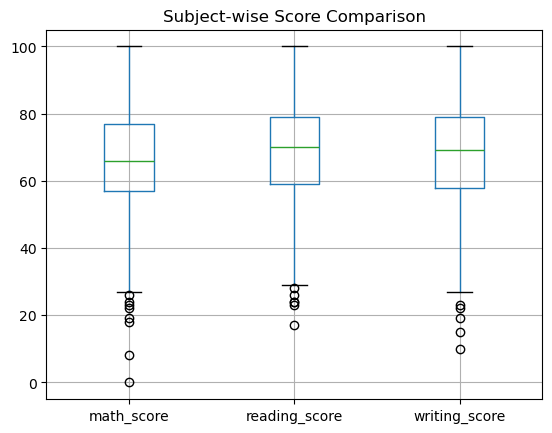

In [39]:
df[
[
"math_score",
"reading_score",
"writing_score"
]
].boxplot()
plt.title('Subject-wise Score Comparison')

plt.savefig(
"C:/Users/prsho/OneDrive/Desktop/ML Projects/ML_EndToEnd_Project/static/images/barplot.png"
)

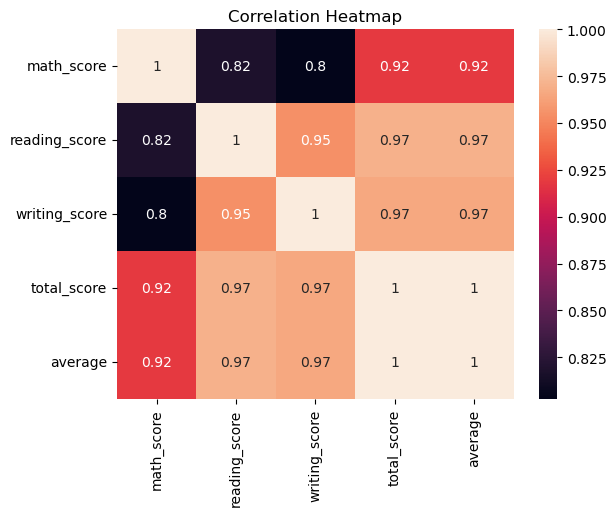

In [41]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)
plt.title('Correlation Heatmap')
plt.savefig(
"C:/Users/prsho/OneDrive/Desktop/ML Projects/ML_EndToEnd_Project/static/images/heatmap.png"
)

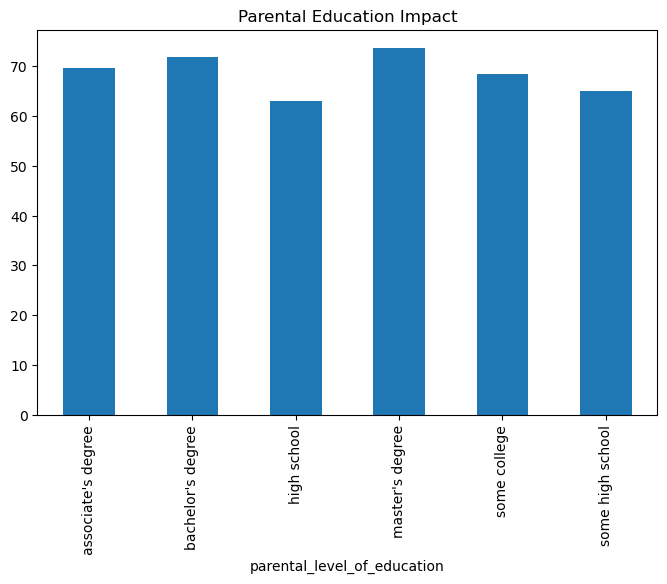

In [45]:
df.groupby(
"parental_level_of_education"
)[
"average"
].mean().plot(
kind="bar",
figsize=(8,5)
)
plt.title('Parental Education Impact')
plt.savefig(
"C:/Users/prsho/OneDrive/Desktop/ML Projects/ML_EndToEnd_Project/static/images/parental_impact.png"
)

<Axes: xlabel='test_preparation_course'>

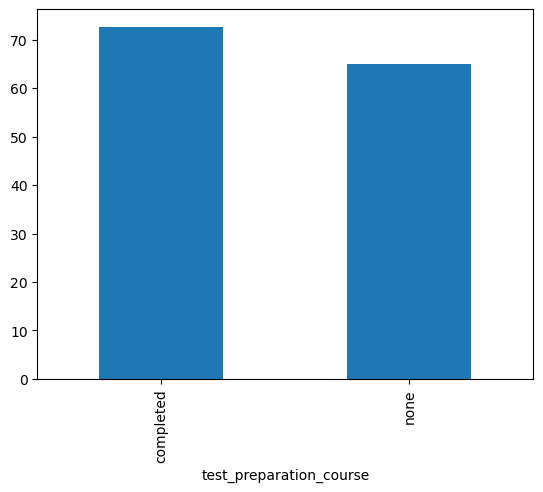

In [46]:
df.groupby(
"test_preparation_course"
)[
"average"
].mean().plot(
kind="bar"
)

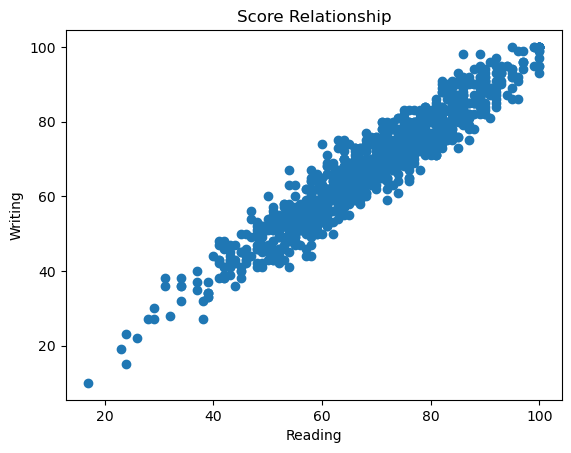

In [48]:
plt.scatter(
df["reading_score"],
df["writing_score"]
)

plt.xlabel("Reading")
plt.ylabel("Writing")
plt.title('Score Relationship')
plt.savefig(
"C:/Users/prsho/OneDrive/Desktop/ML Projects/ML_EndToEnd_Project/static/images/score_relationship.png"
)



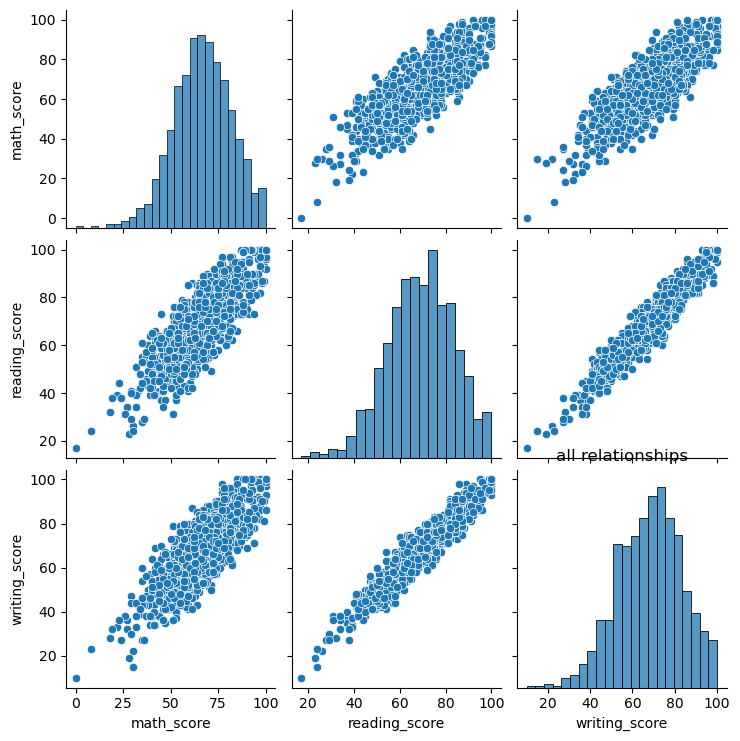

In [50]:
sns.pairplot(
df[
[
"math_score",
"reading_score",
"writing_score"
]
]
)

plt.title('all relationships')
plt.savefig(
"C:/Users/prsho/OneDrive/Desktop/ML Projects/ML_EndToEnd_Project/static/images/all_relationship.png"
)



<Axes: xlabel='gender', ylabel='count'>

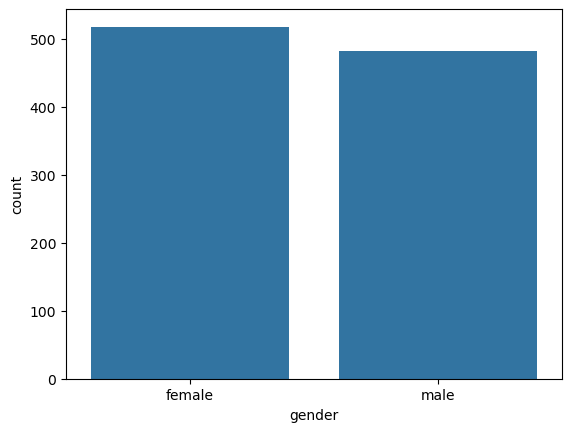

In [51]:
sns.countplot(
x="gender",
data=df
)